In [17]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# parametros do AG
n_pop = 20
quantidade_genes = 10
n_geracoes = 50
pop = []
nova_pop = []
n_cortes = 1
taxa_crossover = 0.8
taxa_mutacao = 0.05
selecao='torneio'

# Random seed
random_seed = 42

# Parametros da sphere
n_dimensoes = quantidade_genes
var_min = -100
var_max = 100

#elitismo
n_elitismo = 2


## Gerar População

In [19]:
# Configurar seed para reprodutibilidade
random.seed(random_seed)
np.random.seed(random_seed)

pop.clear()
#Loop para criar cada indivíduo da população:
for i in range(n_pop):
    cromossomo = [random.uniform(var_min, var_max) for _ in range(n_dimensoes)]
    pop.append(cromossomo)
    #print(f"cromossomo {i+1} gerado: {cromossomo}")
    #print("\n")


In [20]:
#pop

## Função Sphere

In [21]:
def sphere(x):
    """
    Sphere Function
    Mínimo global: f(0, ..., 0) = 0
    """
    return sum(xi**2 for xi in x)

## Avaliar cada individuo 

In [22]:
pop_aval= []
pop_aval.clear()
for cromossomo in pop:
    nota_aval = sphere(cromossomo)
    pop_aval.append((cromossomo, nota_aval))

#pop_aval
    

## Selecionar os individuos mais aptos

In [23]:
def calcular_fitness(pop_avaliada):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)
    Retorna: lista de pesos de fitness
    """
    return [1 / (1 + individuo[1]) for individuo in pop_avaliada]

#def mostrar_probabilidade(pop_avaliada):
#    """
#    Mostra cada cromossomo com sua avaliação e probabilidade relativa
#    """
#    fitness = calcular_fitness(pop_avaliada)
#    total = sum(fitness)
#    probabilidades = [f/total for f in fitness]
#
#    for i, (crom, fitness) in enumerate(pop_avaliada):
#        print(f"Cromossomo {i+1}: avaliação={fitness:.2f}, probabilidade={probabilidades[i]*100:.2f}%")

def selecao_proporcional(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada e quantidade a selecionar
    Retorna: apenas os cromossomos selecionados (sem o valor da sphere)
    """
    fitness = calcular_fitness(pop_avaliada)

    grupo_survivors = random.choices(pop_avaliada, weights=fitness, k=n_pop_selec)
    
    # retorna só os cromossomos, sem o valor da sphere
    return [individuo[0] for individuo in grupo_survivors]

In [24]:
#mostrar_probabilidade(pop_aval)
#len(p1_survivors)

In [25]:
def selecao_torneio(pop_avaliada, n_pop_selec):
    """
    Recebe: população avaliada [(cromossomo, avaliação), ...]
    Retorna: lista de cromossomos selecionados via torneio
    """
    grupo_survivors = []
    for rodada in range(n_pop_selec):
        # sorteiar 2 competidores
        c1, c2 = random.choices(pop_avaliada, k=2)

        # mostrar os competidores
        #print(f"Torneio {rodada+1}:")
        #print(f"  Competidor 1 -> avaliação={c1[1]:.2f}")
        #print(f"  Competidor 2 -> avaliação={c2[1]:.2f}")

        # comparar avaliações (menor é melhor)
        if c1[1] < c2[1]:
            survivor = c1
        else:
            survivor = c2

        #print(f"  Vencedor -> avaliação={survivor[1]:.2f}\n")

        grupo_survivors.append(survivor[0])  # pega só o cromossomo

    return grupo_survivors

In [26]:
def selecionar_pais(selecao, pop_avaliada, n_pop_selec):
    """
    Recebe: lista de tuplas (cromossomo, valor_sphere)          
    :param selecao: 
    :param pop_avaliada: 
    :param n_pop_selec: 
    :return: lista de p1 e p2 selecionados
    """
    if selecao.lower().strip() == 'torneio':
        p1_survivors = selecao_torneio(pop_avaliada, n_pop_selec)
        p2_survivors= selecao_torneio(pop_avaliada, n_pop_selec)
    else:
        p1_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
        p2_survivors = selecao_proporcional(pop_avaliada, n_pop_selec)
    return p1_survivors, p2_survivors


In [27]:
def crossover_1pt(p1, p2, taxa_crossover, quantidade_genes):
    """
    Recebe: dois pais (Selecionados/sobreviventes), taxa de crossover e a quantidade de genes
    Retorna: dois filhos
    """
    # verifica se há cruzamento
    if random.random() < taxa_crossover:
        ponto_corte = random.randint(1, quantidade_genes - 1)
        
        # troca as partes após o ponto de corte
        filho1 = p1[:ponto_corte] + p2[ponto_corte:]
        filho2 = p2[:ponto_corte] + p1[ponto_corte:]
        #print(f"crossover: {filho1} + {filho2}\n")
    else:
        # sem cruzamento, filhos são cópias dos pais
        filho1 = p1[:]
        filho2 = p2[:]
        #print(f"sem crossover: {filho1} + {filho2}\n")
    
    return filho1, filho2

In [28]:
def mutacao(cromossomo, taxa_mutacao, quantidade_genes, var_min, var_max):
    """
    Recebe: cromossomo, quantidade de genes, taxa de mutação e limites
    Retorna: cromossomo (com possíveis mutações)
    """
    cromossomo_mutado = cromossomo[:]  # copia para não alterar o original
    
    for i in range(quantidade_genes):
        if random.random() < taxa_mutacao:
            cromossomo_mutado[i] = random.uniform(var_min, var_max)
            #print(f"mutacao no {i+1}: {cromossomo} ---> {cromossomo_mutado}\n")
    
    return cromossomo_mutado

In [29]:
def gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes,n_pop,
                          taxa_crossover, taxa_mutacao, 
                          var_min, var_max, nova_pop):
    """
    Recebe: listas de pais selecionados, quantidade de genes, a lista de nova populção, taxas e limites
    Retorna: nova população após crossover e mutação
    """
    
    # percorre os pais em pares
    for i in range(0, n_pop):
        
        p1 = random.choice(p1_survivors)
        p2 = random.choice(p2_survivors)
        
        # crossover
        filho1, filho2 = crossover_1pt(p1, p2, taxa_crossover, quantidade_genes)
        
        # mutação em cada filho
        filho1 = mutacao(filho1, taxa_mutacao, quantidade_genes, var_min, var_max)
        filho2 = mutacao(filho2, taxa_mutacao, quantidade_genes, var_min, var_max)
        
        nova_pop.append(filho1)
        nova_pop.append(filho2)
        
    return nova_pop

## Loop exec - Critério de parada - GERAÇÕES

In [30]:
historico_melhor = []
historico_notas = []  # para visualizar a evolução

for geracao in range(n_geracoes):

   # 1. Avaliar população atual
    pop_aval = [(crom, sphere(crom)) for crom in pop]
    
    notas_avaliacao = [aval for _, aval in pop_aval]
    historico_notas.append(notas_avaliacao)

    # 2. Selecionar pais
    p1_survivors, p2_survivors = selecionar_pais(selecao, pop_aval, n_pop)

    # 3. Gerar 60 filhos
    nova_pop.clear()
    gerar_nova_pop(p1_survivors, p2_survivors, quantidade_genes, n_pop,
                   taxa_crossover, taxa_mutacao, var_min, var_max, nova_pop)

    # Avalia todos os 60 filhos, cria lista de tuplas (cromossomo, valor_sphere)
    filhos_aval = [(crom, sphere(crom)) for crom in nova_pop]
    # ordena do menor para o maior pelo valor da sphere (índice [1] da tupla)
    # lambda x: x[1]  significa: "para cada elemento x da lista, use x[1] como critério de ordenação"
    filhos_aval.sort(key=lambda x: x[1])         
    # [:n_pop] fatia a lista: pega só os primeiros 30 (os de menor sphere)
    pop = [ind[0] for ind in filhos_aval[:n_pop]] 
    # filhos_aval[0] é o melhor (já ordenado), [1] é o valor da sphere
    melhor_fitness = filhos_aval[0][1]
    historico_melhor.append(melhor_fitness)
    print(f"Geração {geracao+1:02d} | Melhor fitness: {melhor_fitness:.2f}")
    
# Resultado final
print(f"\n{'='*40}")
print(f"RESULTADO FINAL após {n_geracoes} gerações:")
print(f"Melhor fitness encontrado: {min(historico_melhor):.2f}")
print(f"Geração onde ocorreu: {historico_melhor.index(min(historico_melhor)) + 1}")


Geração 01 | Melhor fitness: 16406.84
Geração 02 | Melhor fitness: 9644.12
Geração 03 | Melhor fitness: 9644.12
Geração 04 | Melhor fitness: 9644.12
Geração 05 | Melhor fitness: 5125.09
Geração 06 | Melhor fitness: 5822.85
Geração 07 | Melhor fitness: 5083.28
Geração 08 | Melhor fitness: 4385.52
Geração 09 | Melhor fitness: 4385.52
Geração 10 | Melhor fitness: 4140.51
Geração 11 | Melhor fitness: 4140.51
Geração 12 | Melhor fitness: 3229.81
Geração 13 | Melhor fitness: 3933.12
Geração 14 | Melhor fitness: 1677.49
Geração 15 | Melhor fitness: 1677.49
Geração 16 | Melhor fitness: 1677.49
Geração 17 | Melhor fitness: 534.41
Geração 18 | Melhor fitness: 535.59
Geração 19 | Melhor fitness: 535.59
Geração 20 | Melhor fitness: 535.59
Geração 21 | Melhor fitness: 535.59
Geração 22 | Melhor fitness: 535.59
Geração 23 | Melhor fitness: 350.91
Geração 24 | Melhor fitness: 276.65
Geração 25 | Melhor fitness: 276.65
Geração 26 | Melhor fitness: 266.58
Geração 27 | Melhor fitness: 266.58
Geração 28 

In [31]:
p1_survivors, p2_survivors = selecionar_pais(selecao, pop_aval, n_pop)

## Gráficos

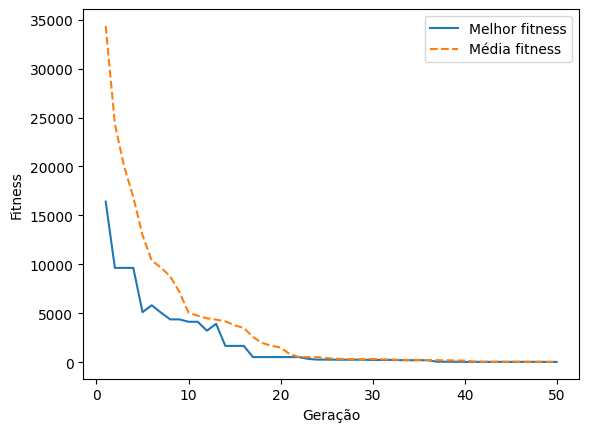

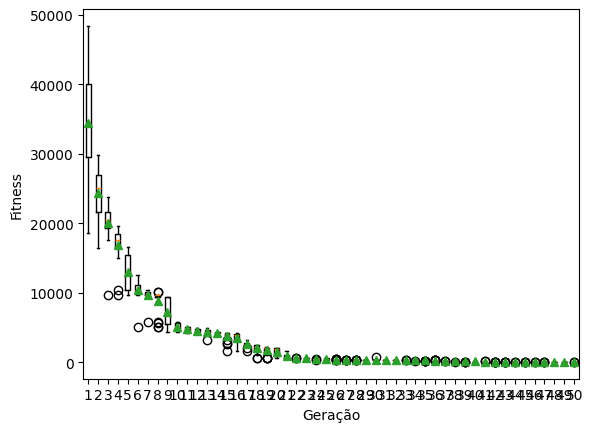

In [32]:
# Gráfico de convergência
media_por_geracao = [np.mean(gen) for gen in historico_notas]
plt.plot(range(1, n_geracoes+1), historico_melhor, label="Melhor fitness")
plt.plot(range(1, n_geracoes+1), media_por_geracao, label="Média fitness", linestyle="--")
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.legend()
plt.show()

# Boxplot
plt.boxplot(historico_notas, positions=range(1, n_geracoes+1), showmeans=True)
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.show()